# BPL_TEST2_Chemostat - demo

In [1]:
# Import the application model and context variables
from BPL_TEST2_Chemostat import*

Windows - run FMU pre-compiled JModelica 2.14


In [2]:
# Impprt the general FMU_explore functions ana adapt them to the application
from fmu_explore_pyfmi import fmu_explore

Dummy = fmu_explore(model, parValue, parLocation, parCheck,  fmu_model, fmu_process_diagram, \
                    MSL_usage, MSL_version, BPL_version, \
                    opts_std, simulationTime, timeDiscreteStates, stateValue, \
                    diagrams, ax, lines, external_function = cstrProdMax)
par = Dummy.par
init = Dummy.init
disp = Dummy.disp
simu = Dummy.simu
show = Dummy.show
resetPen = Dummy.resetPen
process_diagram = Dummy.process_diagram
describe_general = Dummy.describe_general
describe_parts = Dummy.describe_parts
describe_MSL = Dummy.describe_MSL
FMU_explore_info = Dummy.FMU_explore_info
system_info = Dummy.system_info
SDG = Dummy.SDG
cstrProdMax = Dummy.external_function

Bring in the user defined FMU_explore functions describe() and newplot(

In [3]:
run -i BPL_TEST2_Chemostat_explore.py


Model for the process has been setup. Key commands:
 - par()       - change of parameters and initial values
 - init()      - change initial values only
 - simu()      - simulate and plot
 - newplot()   - make a new plot
 - show()      - show plot from previous simulation
 - disp()      - display parameters and initial values from the last simulation
 - describe()  - describe culture, broth, parameters, variables with values/units

Note that both disp() and describe() takes values from the last simulation
and the command process_diagram() brings up the main configuration

Brief information about a command by help(), eg help(simu)
Key system information is listed with the command system_info()


In [4]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [25/2.54, 20/2.54]

No processDiagram.png file in the FMU, but try the file on disk.


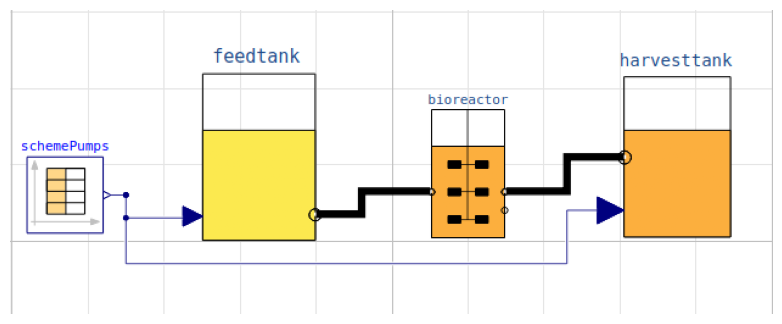

In [5]:
process_diagram()

In [6]:
#fmu_model ='xBPL_TEST2_Chemostat_linux_om_me.fmu'    
#model = load_fmu(fmu_model, log_level=0)

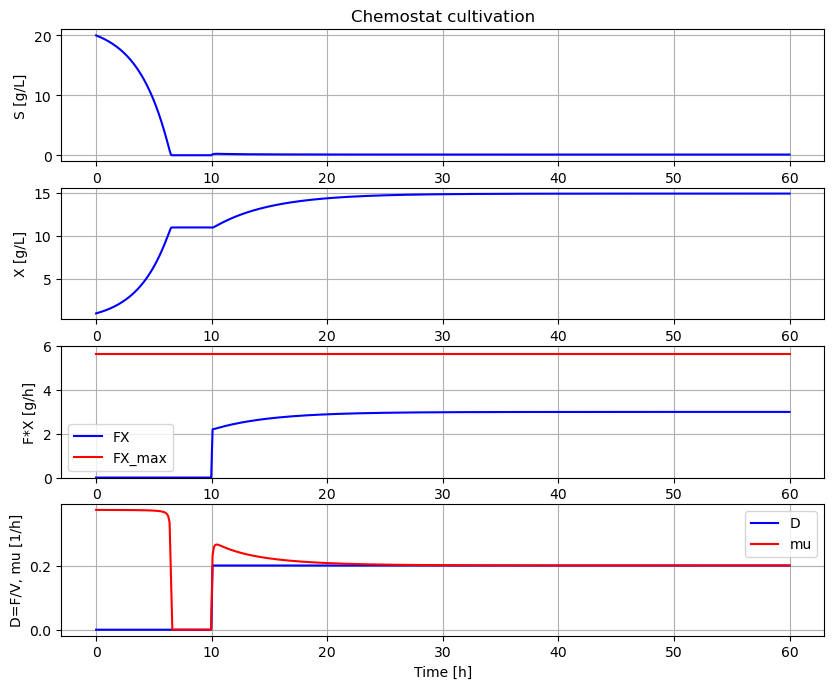

In [7]:
newplot(); ax[2].set_ylim([0, 6])
par(Y=0.50, qSmax=0.75,  Ks=0.1)               # Culture parameters
init(V_start=1.0, VX_start=1.0, VS_start=20)   # Bioreactor startup
par(S_in=30, t0=0, F0=0, t1=10, F1=0.2)        # Substrate feeding
simu(60)

In [8]:
# The maximal biomass productivity FX_max [g/h] marked red in the diagram above
# can be calculated for CSTR from the FMU and is
cstrProdMax(model)

np.float64(5.625)

In [9]:
describe('cstrProdMax')

Calculate from the model maximal chemostat productivity FX_max : 5.625 [ g/h ]


In [10]:
disp('culture')

Y : 0.5
qSmax : 0.75
Ks : 0.1


In [11]:
describe('mu')

Cell specific growth rate variable : 0.2 [ 1/h ]


In [12]:
describe('parts')

['bioreactor', 'bioreactor.culture', 'D', 'feedtank', 'harvesttank', 'MSL', 'schemePumps']


In [13]:
describe('MSL')

MSL: RealInput, RealOutput, CombiTimeTable, Types


In [14]:
system_info()


System information
 -OS: Windows
 -Python: 3.12.11
 -Scipy: not installed in the notebook
 -PyFMI: 2.21.0
 -FMU by: JModelica.org
 -FMI: 2.0
 -Type: FMUModelCS2
 -Name: BPL.Examples_TEST2.Chemostat
 -Generated: 2025-07-26T09:39:44
 -MSL: 3.2.2 build 3
 -Description: Bioprocess Library version 2.3.1
 -Interaction: FMU-explore version 1.1.4


In [15]:
cstrProdMax()

np.float64(5.625)